In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashura369/late-delivery-prediction/APL_Logistics.csv", encoding='latin1')

In [3]:
with pd.option_context('display.max_columns', None):
    display(df.head(6))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class
5,DEBIT,6,4,105.63,290.98,Late delivery,1,43,Camping & Hiking,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,9.00,0.03,299.98,0.36,1,299.98,290.98,105.63,East of USA,Nueva York,COMPLETE,Diamondback Women's Serene Classic Comfort Bi,299.98,Standard Class


In [4]:
# checking for null values
print(df.isna().sum())

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [5]:
# checking for total samples and features
print(f"TOTAL SAMPLES : {df.shape[0]}\nTOTAL FEATURES : {df.shape[1]}")

TOTAL SAMPLES : 180519
TOTAL FEATURES : 40


In [6]:
# printing the column names, data type they contain, total number of unique values, and the content they hold (unique values only)

context = [df[col].unique().tolist() for col in df.columns]

# making a dataset for entire overview
overview = pd.DataFrame({
    'DTYPES' : df.dtypes,
    'NO. OF UNIQUE VALUES' : df.nunique(),
    'CONTENT' : context
})

In [7]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(overview)

,DTYPES,NO. OF UNIQUE VALUES,CONTENT
Type,object,4,"[DEBIT, PAYMENT, TRANSFER, CASH]"
Days for shipping (real),int64,7,"[6, 4, 3, 0, 5, 2, 1]"
Days for shipment (scheduled),int64,4,"[4, 0, 1, 2]"
Benefit per order,float64,21998,"[159.69, 48.71, 87.36, -41.89, 10.0, 105.63, 64.1, 22.67, 3.52, 40.34, -131.7, 34.5, 10.8, -42.61, 27.41, -140.73, 11.4, 46.51, -274.39, 83.69, 108.23, 11.25, 66.62, 43.16, 2.99, 39.36, 117.58, 111.73, 76.99, -445.21, 17.22, 33.25, -70.36, -41.77, 48.66, 59.39, 26.99, 3.37, 23.23, 11.88, -21.0, -119.92, 34.29, 78.91, 51.16, 53.55, 47.92, 21.77, 27.29, 29.25, 75.2, 215.98, 56.83, 25.48, 143.99, 111.04, 19.07, 91.52, 0.0, 46.97, 45.35, -63.64, 38.52, 50.38, 36.96, 45.82, 42.25, 97.49, 78.74, 7.43, 34.13, -250.1, 153.43, 54.28, 49.72, 2.79, 74.79, 1.12, 41.98, 132.29, 72.03, 52.38, 125.73, -17.4, 165.99, 24.53, 109.43, 89.3, 180.58, 18.41, 20.16, 89.24, 30.0, 4.18, 120.11, 63.45, 44.8, -43.76, 25.05, 45.0, ...]"
Sales per customer,float64,2927,"[472.45, 167.96, 181.99, 175.99, 40.0, 290.98, 142.44, 83.97, 351.98, 98.38, 84.97, 74.99, 24.35, 94.5, 191.99, 189.99, 98.96, 391.98, 269.98, 263.98, 90.0, 141.75, 107.89, 248.98, 245.98, 235.16, 232.76, 245.96, 251.96, 49.19, 95.98, 56.99, 143.98, 134.98, 119.95, 18.74, 70.38, 118.78, 84.0, 139.44, 97.96, 208.77, 106.59, 254.98, 145.21, 197.92, 90.96, 97.49, 160.0, 479.95, 195.95, 91.0, 299.97, 236.25, 116.99, 161.97, 82.97, 81.97, 209.92, 127.45, 129.99, 299.98, 224.99, 99.0, 169.98, 136.5, 374.96, 464.95, 113.09, 110.49, 232.41, 37.49, 149.94, 377.98, 147.0, 145.5, 371.98, 347.98, 335.98, 331.98, 52.19, 287.98, 190.0, 419.96, 197.98, 40.02, 126.0, 194.0, 200.0, 104.45, 272.98, 135.0, 159.99, 179.99, 237.41, 130.45, 24.24, 169.96, 149.99, 284.99, ...]"
Delivery Status,object,4,"[Late delivery, Shipping on time, Advance shipping, Shipping canceled]"
Late_delivery_risk,int64,2,"[1, 0]"
Category Id,int64,51,"[9, 29, 48, 24, 43, 46, 45, 17, 13, 18, 40, 11, 41, 3, 35, 30, 36, 7, 33, 37, 12, 32, 26, 16, 5, 6, 38, 10, 2, 34, 44, 31, 4, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]"
Category Name,object,50,"[Cardio Equipment, Shop By Sport, Water Sports, Women's Apparel, Camping & Hiking, Indoor/Outdoor Games, Fishing, Cleats, Electronics, Men's Footwear, Accessories, Fitness Accessories, Trade-In, Baseball & Softball, Golf Gloves, Men's Golf Clubs, Golf Balls, Hockey, Golf Shoes, Boxing & MMA, Golf Apparel, Girls' Apparel, As Seen on TV!, Lacrosse, Tennis & Racquet, Kids' Golf Clubs, Strength Training, Soccer, Golf Bags & Carts, Hunting & Shooting, Women's Golf Clubs, Basketball, Books , Baby , CDs , Cameras , Children's Clothing, Computers, Consumer Electronics, Crafts, DVDs, Garden, Health and Beauty, Men's Clothing, Music, Pet Supplies, Sporting Goods, Toys, Video Games, Women's Clothing]"
Customer City,object,563,"[Brownsville, Littleton, Caguas, San Marcos, Passaic, Lawrence, Stafford, San Antonio, Pico Rivera, Fontana, Taylor, Martinez, West New York, North Bergen, San Juan, Peoria, Glenview, Longview, Fort Worth, Albuquerque, Norfolk, Oceanside, Opelousas, Long Beach, Brooklyn, Duluth, Napa, Denver, Freeport, Strongsville, San Bernardino, Chicago, Roswell, Phoenix, Baltimore, Sunnyvale, Webster, Princeton, Los Angeles, Philadelphia, Vista, Jacksonville, Parkville, Knoxville, Ithaca, Tampa, Atlanta, Escondido, Spring, Annapolis, Hyattsville, Las Vegas, Dorchester Center, Broomfield, Saint Paul, Bronx, Beaverton, Middletown, Bellflower, West Covina, La Crosse, Ogden, Cincinnati, Bend, Oxnard, Amarillo, Augusta, Aurora, Methuen, Lynn, Broken Arrow, San Diego, Opa Locka, Dayton, Hanover, Colton, Union, Richmond, Hollywood, Brandon, Citrus Heights, Corona, Hialeah, Rio Rancho, Antioch, Florissant, Columbus, Chino, Lombard, Dundalk, Irwin, Hayward, Lindenhurst, Louisville, Portland, Gaithersburg, Modesto, Dearborn, Lancaster, Pompano Beach, ...]"


### Observation

In this step, we drop columns that are not useful for our descriptive analysis and visualization. Removing these columns helps reduce memory usage, declutters the DataFrame, and makes it easier to display tables and plots.

**The columns are to be removed based on the following categories:**

1. **Personally Identifiable Information (PII) & Privacy:**
   * `Customer Fname` & `Customer Lname`: Customer names are unique to individuals and do not provide any aggregatable business insights.
   * `Customer Street`: Street-level addresses are too granular for high-level geographic charts.

2. **Database Keys & Unique Identifiers (IDs):**
   * `Customer Id`, `Order Customer Id`, `Category Id`, and `Department Id`: These are database keys used for table joins. For visualization, the descriptive names (like `Category Name` or `Department Name`) are used instead of numeric IDs.

3. **Redundant Columns:**
   * `Order Item Product Price`: This is redundant since we already have `Product Price`.
   * `Customer Zipcode`: Zip codes have too many unique values to visualize effectively on charts (we use broader regions like `Customer State` or `Customer City` instead).

4. **Excluded Metrics (Optional):**
   * `Order Profit Per Order`: Excluded from this specific visualization subset because we already have a similar column to this.

In [8]:
df = df.drop(columns=['Days for shipping (real)','Benefit per order','Sales per customer','Category Id','Customer Fname','Order Status','Customer Lname','Customer Id','Customer Street','Department Id','Order Customer Id','Order Item Product Price','Order Profit Per Order'])

In [9]:
print(df.columns)
print('\nREMAINING COLUMNS : ', len(df.columns))
print(f"TOTAL NO. OF COLUMNS REMOVED : {40 - 27}")

Index(['Type', 'Days for shipment (scheduled)', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Name', 'Latitude', 'Longitude',
       'Market', 'Order City', 'Order Country', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region',
       'Order State', 'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='object')

REMAINING COLUMNS :  27
TOTAL NO. OF COLUMNS REMOVED : 13


#### Changing The Columns Names For Better Understanding

In [10]:
df = df.rename(columns={
    'Type' : 'Payment Method',
    'Late_delivery_risk' : 'Late Delivery ?',
    'Category Name' : 'Product Category',
    'Sales' : 'Total Sales',
    'Order Item Total' : 'Price After Discount'
})

#### Making Another Separate Data Type For `int` And `float`

In [11]:
int_df = df.select_dtypes([int, float])
int_df.drop(columns=['Late Delivery ?','Customer Zipcode','Latitude','Longitude'], inplace=True)                # dropping output feature
int_df.sample(6)

,Days for shipment (scheduled),Order Item Discount,Order Item Discount Rate,Order Item Profit Ratio,Order Item Quantity,Total Sales,Price After Discount,Product Price
99537,1,24.99,0.25,0.08,2,99.96,74.97,49.98
150751,4,11.00,0.06,0.05,1,199.99,188.99,199.99
141656,4,26.00,0.20,0.47,1,129.99,103.99,129.99
29851,4,9.00,0.09,0.11,1,99.99,90.99,99.99
10456,2,40.00,0.20,0.13,1,199.99,159.99,199.99
108022,4,27.00,0.09,0.35,1,299.98,272.98,299.98


#### Checking For Distribution Of Data For Each Column

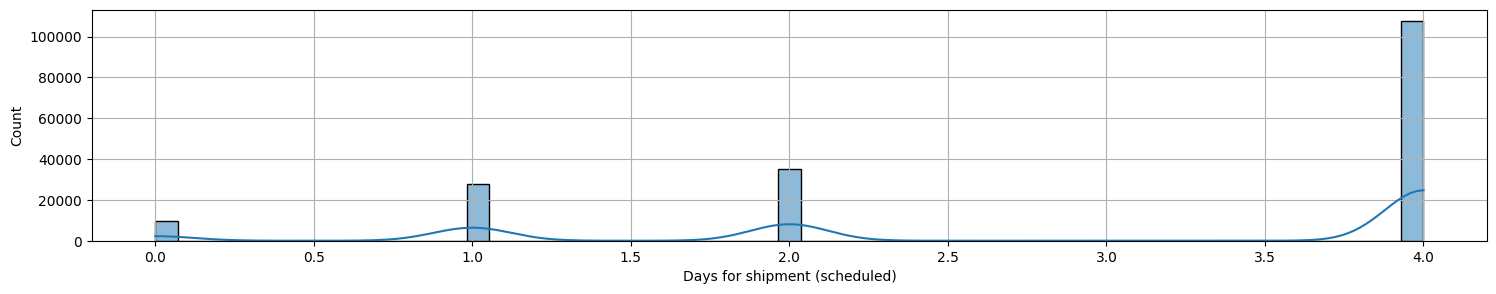

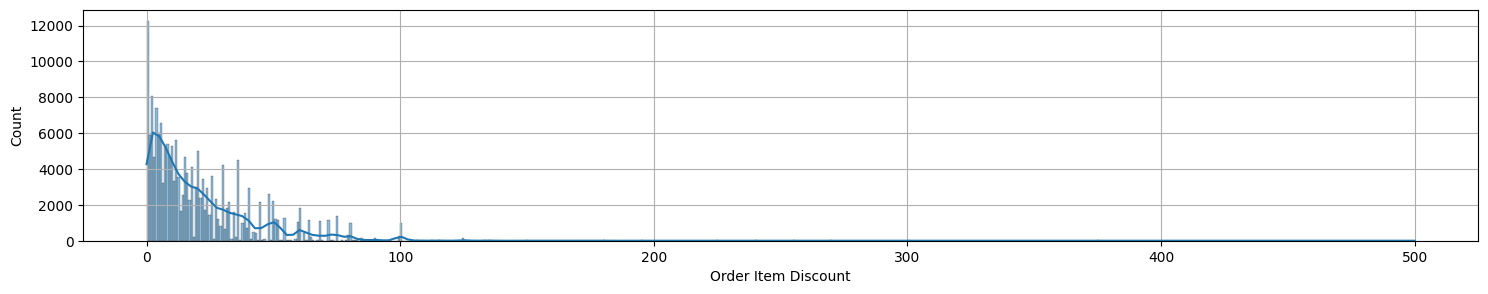

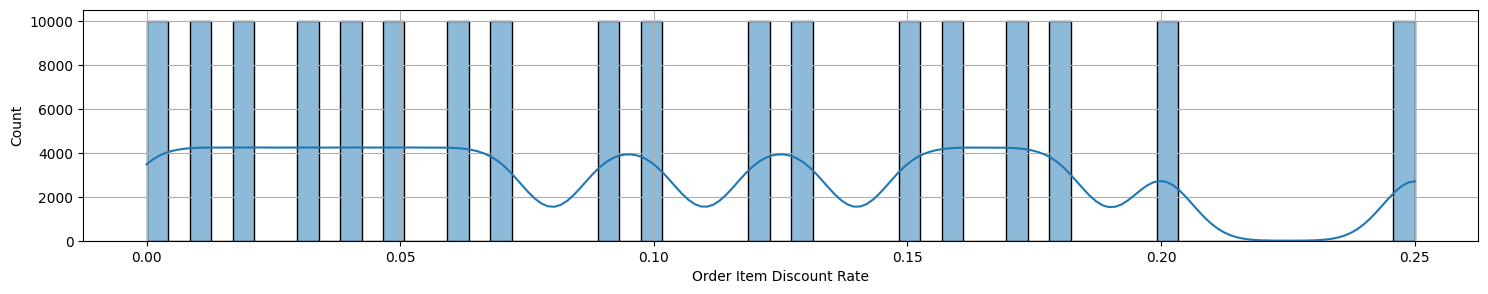

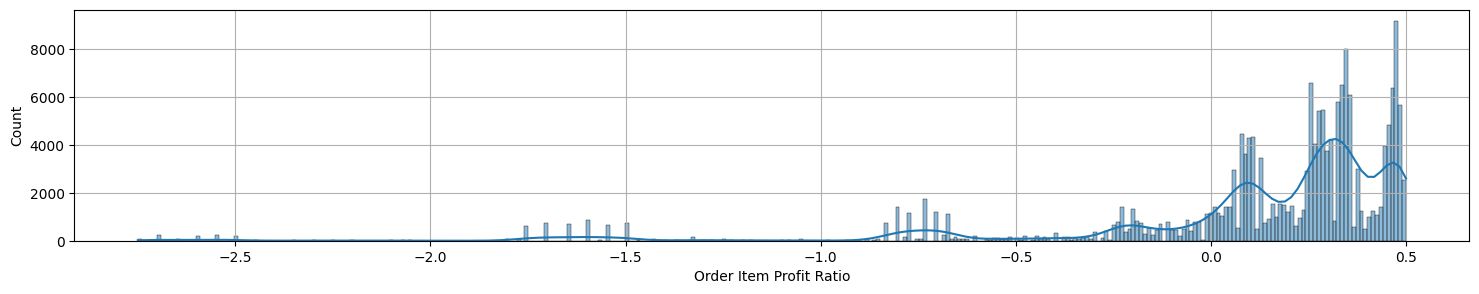

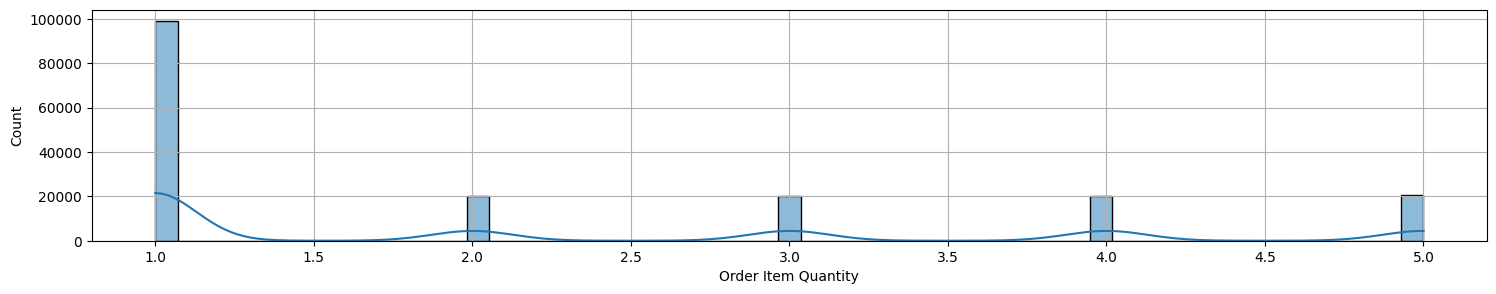

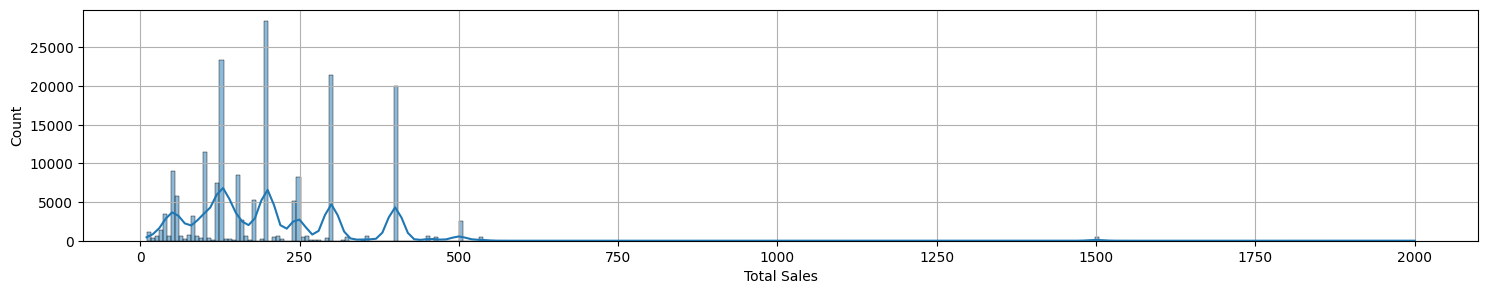

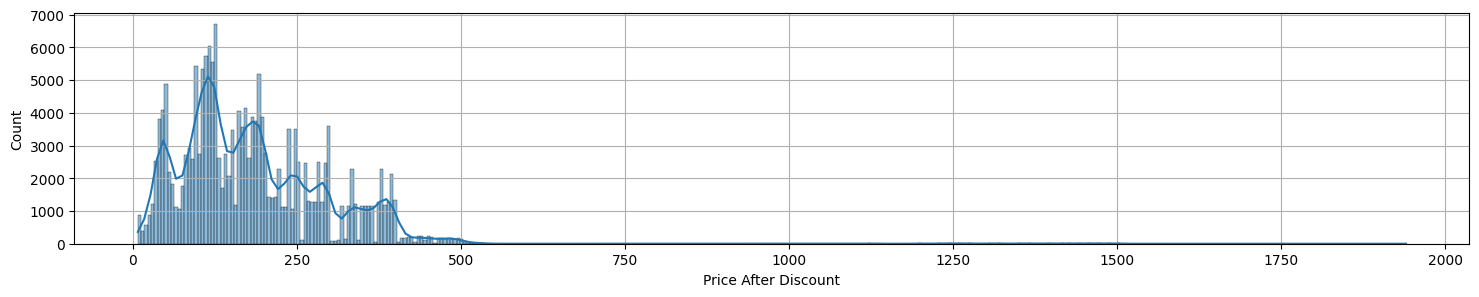

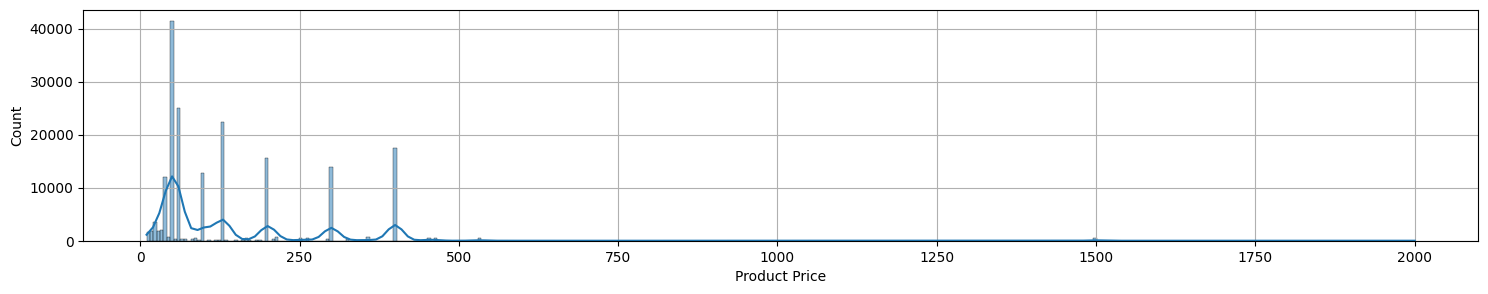

In [12]:
for col in int_df.columns:
    plt.figure(figsize=(18,3))
    sns.histplot(x=int_df[col], kde=True)
    plt.grid(True)
plt.show()

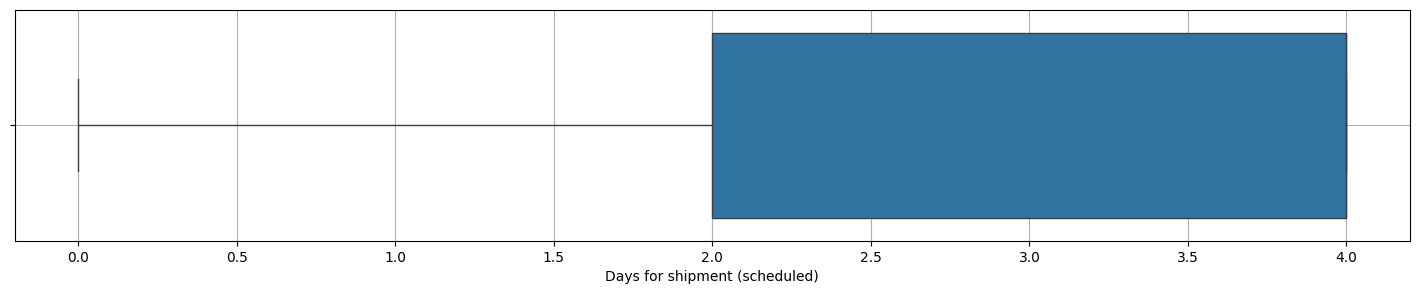

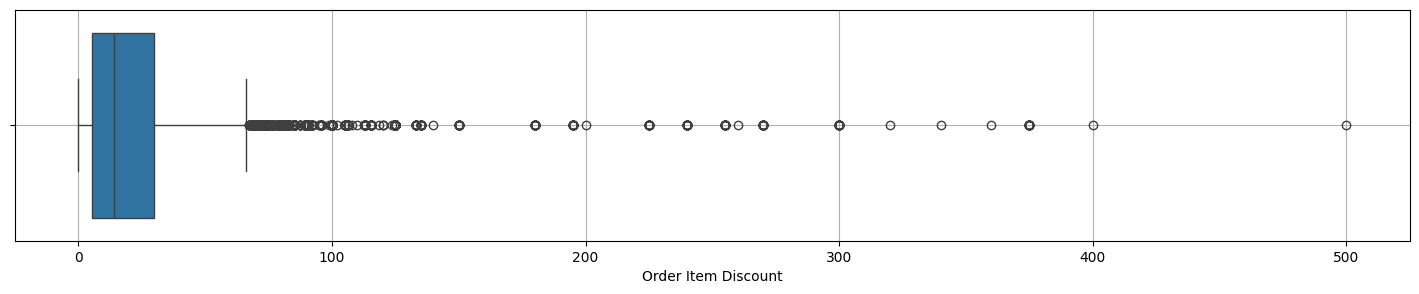

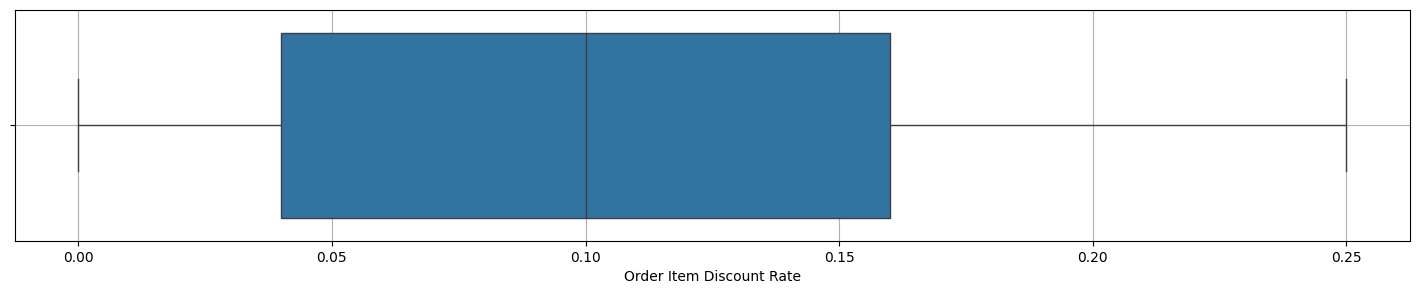

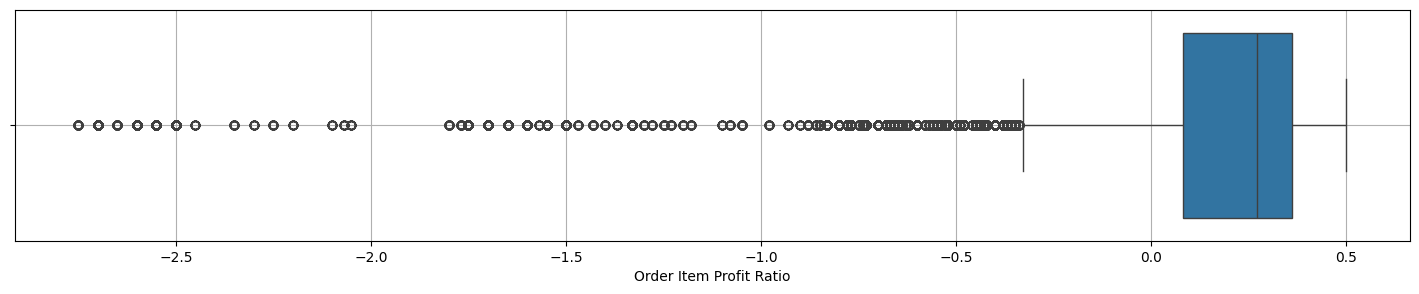

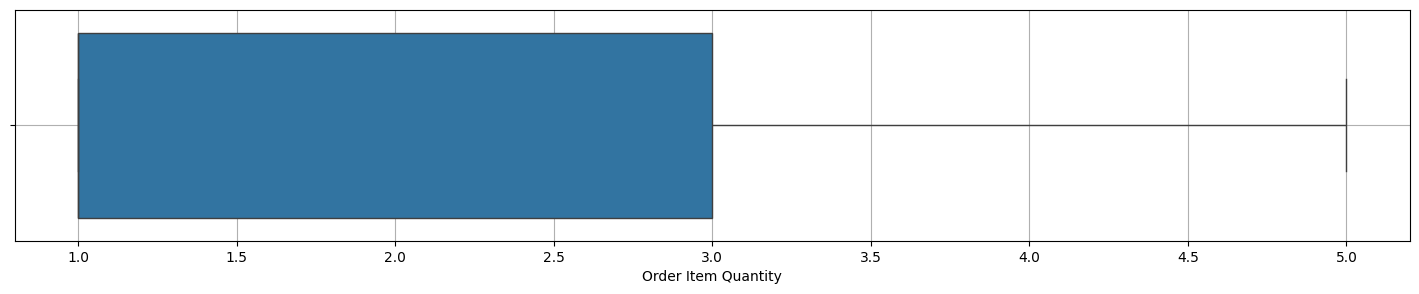

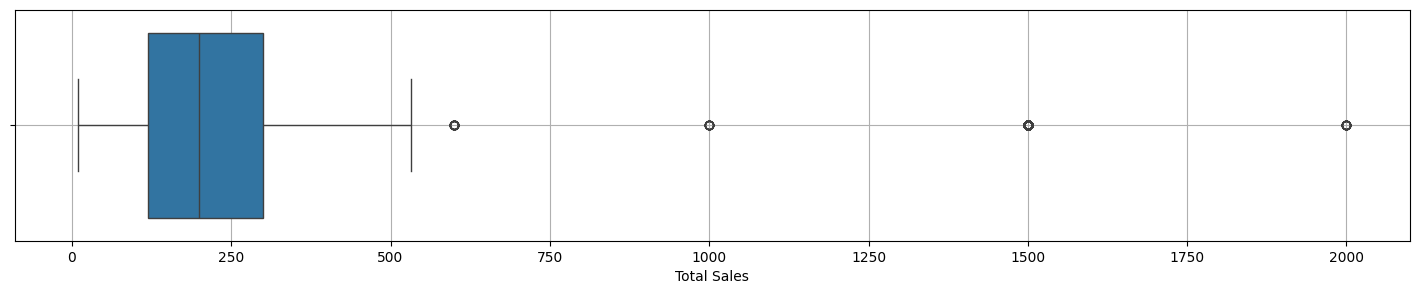

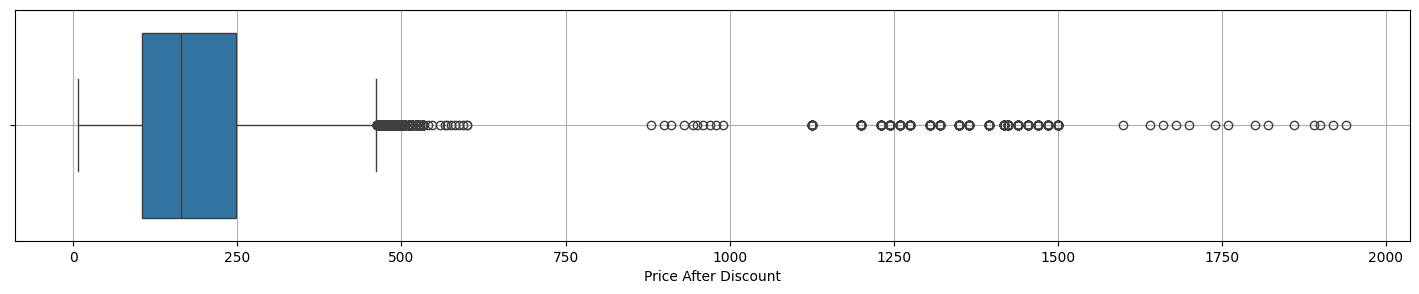

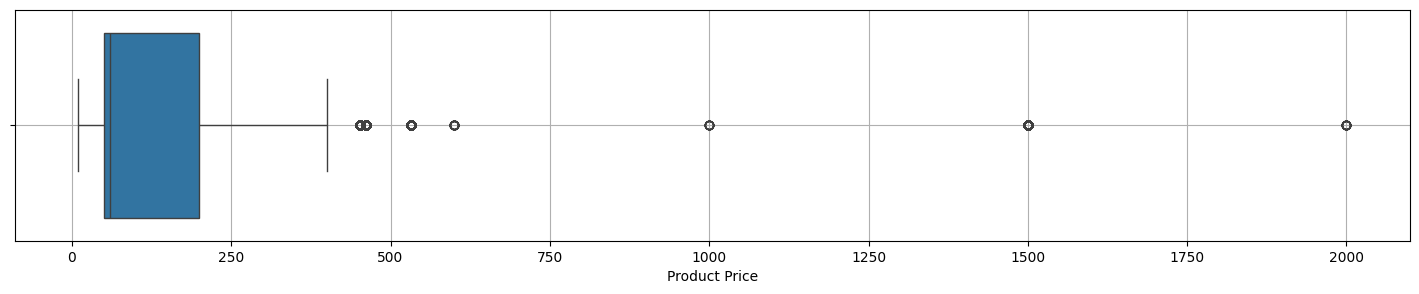

In [25]:
for col in int_df.columns:
    plt.figure(figsize=(18,3))
    sns.boxplot(x=int_df[col])
    plt.grid(True)
plt.show()

## **OBSERVATION**
- Outlier detected in `Price After Discount`, and `Produce Price`
    - We should keep the outliers as it is because, we are going to use Tree Baed Models, which tend to perform better even on outlier data.

#### Checking The Outlier Features

In [24]:
int_df[['Price After Discount', 'Product Price']].describe()

,Price After Discount,Product Price
count,180519.000000,180519.000000
mean,183.107607,141.232547
std,120.043668,139.732489
min,7.490000,9.990000
25%,104.380000,50.000000
50%,163.990000,59.990000
75%,247.400000,199.990000
max,1939.990000,1999.990000


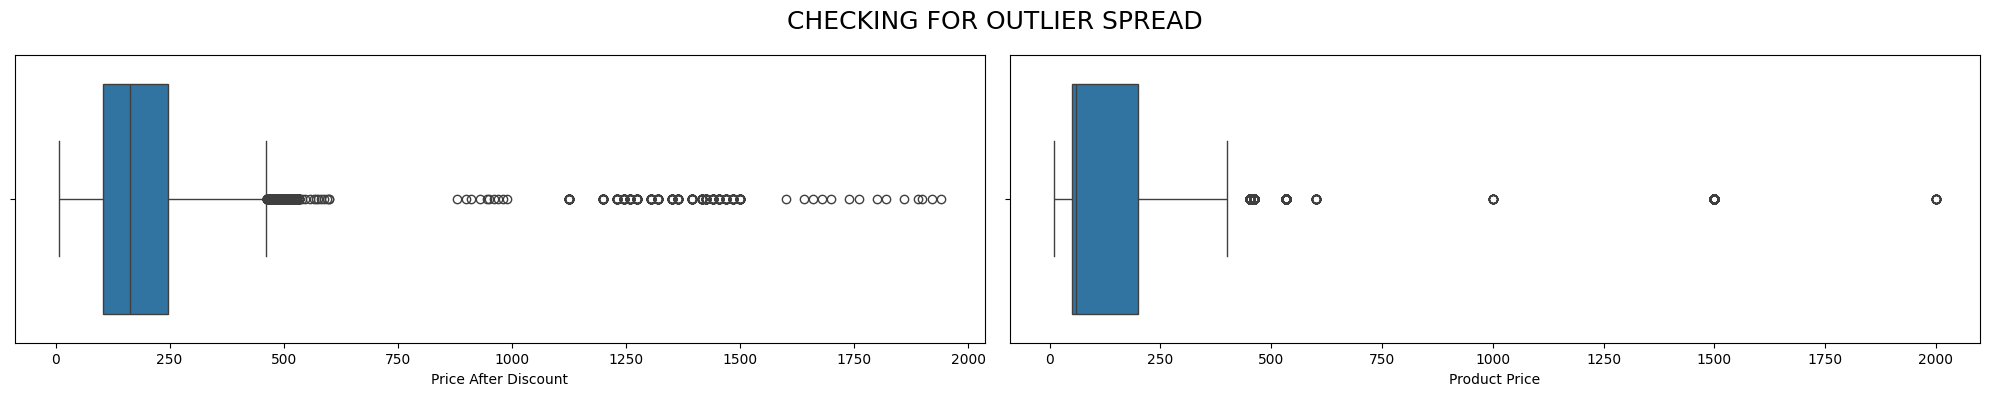

In [16]:
plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.boxplot(x=int_df['Price After Discount'])
plt.subplot(1,2,2)
sns.boxplot(x=int_df['Product Price'])

plt.suptitle('CHECKING FOR OUTLIER SPREAD', fontsize=18)
plt.tight_layout()
plt.show()

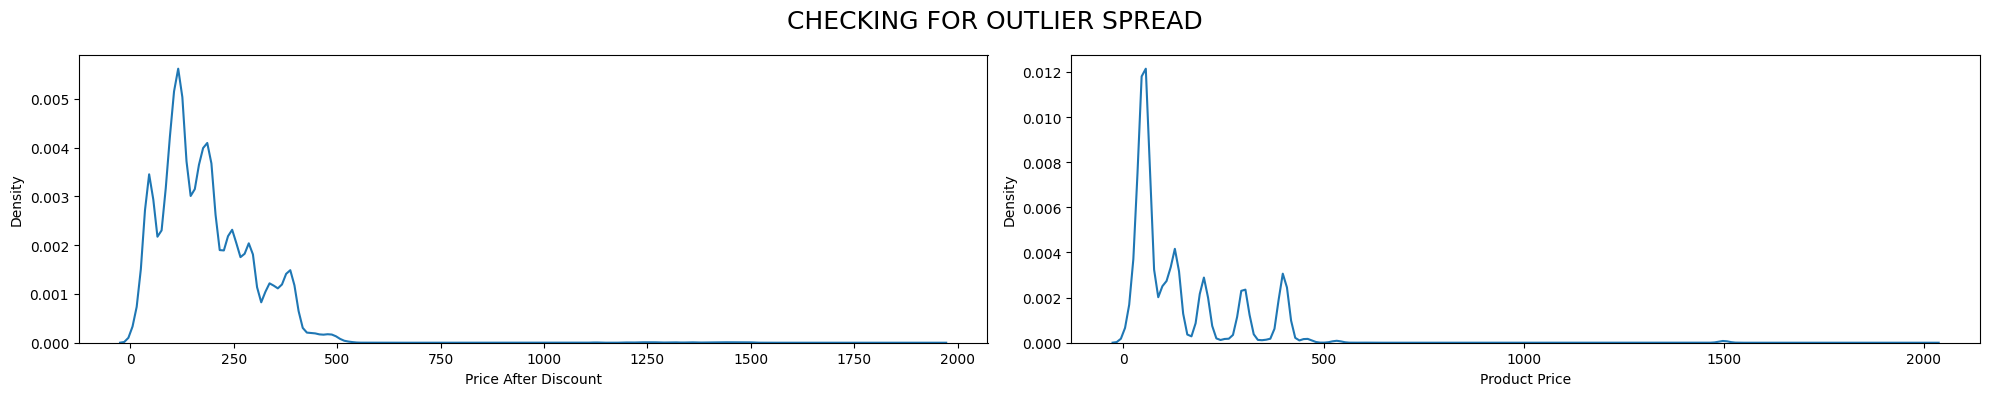

In [17]:
plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.kdeplot(x=int_df['Price After Discount'])
plt.subplot(1,2,2)
sns.kdeplot(x=int_df['Product Price'])

plt.suptitle('CHECKING FOR OUTLIER SPREAD', fontsize=18)
plt.tight_layout()
plt.show()

### Checking For Imbalanced Dataset

In [50]:
print(np.round(df['Late Delivery ?'].value_counts(normalize=True) * 100, 2))

Late Delivery ?
1    54.83
0    45.17
Name: proportion, dtype: float64


### Separating All Categorical Features For Encoding

In [51]:
cat_df = df.select_dtypes(exclude=[int,float,bool])

In [52]:
cat_df

,Payment Method,Delivery Status,Product Category,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Region,Order State,Product Name,Shipping Mode
0,DEBIT,Late delivery,Cardio Equipment,Brownsville,EE. UU.,Consumer,TX,Footwear,Pacific Asia,Mumbai,India,South Asia,Maharashtra,Nike Men's Free 5.0+ Running Shoe,Standard Class
1,DEBIT,Shipping on time,Shop By Sport,Littleton,EE. UU.,Consumer,CO,Golf,LATAM,San Pedro Sula,Honduras,Central America,Cortés,Under Armour Girls' Toddler Spine Surge Runni,Standard Class
2,DEBIT,Shipping on time,Water Sports,Littleton,EE. UU.,Consumer,CO,Fan Shop,LATAM,San Pedro Sula,Honduras,Central America,Cortés,Pelican Sunstream 100 Kayak,Standard Class
3,DEBIT,Late delivery,Water Sports,Littleton,EE. UU.,Consumer,CO,Fan Shop,USCA,New York City,Estados Unidos,East of USA,Nueva York,Pelican Sunstream 100 Kayak,Standard Class
4,DEBIT,Late delivery,Women's Apparel,Littleton,EE. UU.,Consumer,CO,Golf,USCA,New York City,Estados Unidos,East of USA,Nueva York,Nike Men's Dri-FIT Victory Golf Polo,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,TRANSFER,Late delivery,Women's Clothing,Caguas,Puerto Rico,Consumer,PR,Apparel,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,Summer dresses,Standard Class
180515,DEBIT,Advance shipping,Women's Clothing,Plainfield,EE. UU.,Consumer,IL,Apparel,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,Summer dresses,Standard Class
180516,DEBIT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,Smart watch,Standard Class
180517,PAYMENT,Shipping on time,Toys,Berwyn,EE. UU.,Corporate,IL,Fan Shop,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,Toys,Standard Class
